<a href="https://colab.research.google.com/github/brunobobadilla06/Proyecto-Final---Bobadilla---Ciencia-de-Datos-III/blob/main/Proyecto_Final_Bobadilla_Ciencia_de_Datos_III.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# PROYECTO FINAL - CIENCIA DE DATOS III
# "DEL TOKEN AL TENSOR"
# ============================================================

# ============================================================
# 1. CONFIGURACIÓN DEL ENTORNO
# ============================================================

!pip install -q datasets spacy nltk scikit-learn torch matplotlib seaborn wordcloud
!python -m spacy download es_core_news_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 95.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
# ============================================================
# 2. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import spacy
import torch
import torch.nn as nn
import torch.optim as optim

from datasets import load_dataset
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from torch.utils.data import TensorDataset, DataLoader

nltk.download("punkt")
nltk.download("stopwords")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo utilizado:", device)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Dispositivo utilizado: cpu


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
# ============================================================
# 3. CARGA DEL DATASET
# ============================================================

dataset = load_dataset("mteb/SpanishSentimentClassification")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/6.34k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/59.6k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/18.7k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1029 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/147 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/296 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1029
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 147
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 296
    })
})


In [4]:
# ============================================================
# 4. CONVERSIÓN A DATAFRAME
# ============================================================

# Unimos los splits disponibles en un solo DataFrame
dataframes = []

for split in dataset.keys():
    temp_df = dataset[split].to_pandas()
    temp_df["split_original"] = split
    dataframes.append(temp_df)

df = pd.concat(dataframes, ignore_index=True)

print("Cantidad total de registros:", len(df))
print("Columnas disponibles:")
print(df.columns)
df.head()

Cantidad total de registros: 1472
Columnas disponibles:
Index(['text', 'label', 'split_original'], dtype='object')


,text,label,split_original
0,"Está situado en el centro de la ciudad , con t...",1,train
1,"un lugar hermosisimo , inolvidable. hermosa at...",1,train
2,Todo absolutamente recomendable .,1,train
3,El metro está a 50 metros bajando tan solo una...,1,train
4,Y de Toscana ... mejor que lo veais ... y adem...,1,train


In [5]:
# ============================================================
# 4. CONVERSIÓN A DATAFRAME
# ============================================================

# Unimos los splits disponibles en un solo DataFrame
dataframes = []

for split in dataset.keys():
    temp_df = dataset[split].to_pandas()
    temp_df["split_original"] = split
    dataframes.append(temp_df)

df = pd.concat(dataframes, ignore_index=True)

print("Cantidad total de registros:", len(df))
print("Columnas disponibles:")
print(df.columns)
df.head()

Cantidad total de registros: 1472
Columnas disponibles:
Index(['text', 'label', 'split_original'], dtype='object')


,text,label,split_original
0,"Está situado en el centro de la ciudad , con t...",1,train
1,"un lugar hermosisimo , inolvidable. hermosa at...",1,train
2,Todo absolutamente recomendable .,1,train
3,El metro está a 50 metros bajando tan solo una...,1,train
4,Y de Toscana ... mejor que lo veais ... y adem...,1,train


In [6]:
# ============================================================
# 5. DETECCIÓN DE COLUMNAS DE TEXTO Y ETIQUETA
# ============================================================

# Buscamos automáticamente columnas típicas
posibles_textos = ["text", "sentence", "review", "content", "tweet"]
posibles_labels = ["label", "labels", "sentiment", "category"]

col_texto = None
col_label = None

for col in df.columns:
    if col.lower() in posibles_textos:
        col_texto = col

for col in df.columns:
    if col.lower() in posibles_labels:
        col_label = col

print("Columna de texto detectada:", col_texto)
print("Columna de etiqueta detectada:", col_label)

df = df[[col_texto, col_label]].copy()
df.columns = ["texto", "etiqueta"]

df.head()

Columna de texto detectada: text
Columna de etiqueta detectada: label


,texto,etiqueta
0,"Está situado en el centro de la ciudad , con t...",1
1,"un lugar hermosisimo , inolvidable. hermosa at...",1
2,Todo absolutamente recomendable .,1
3,El metro está a 50 metros bajando tan solo una...,1
4,Y de Toscana ... mejor que lo veais ... y adem...,1


In [7]:
# ============================================================
# 6. VALIDACIÓN DEL DATASET
# ============================================================

print("Cantidad de registros:", len(df))
print("Cantidad de clases:", df["etiqueta"].nunique())
print("Valores nulos:")
print(df.isnull().sum())

df = df.dropna().drop_duplicates().reset_index(drop=True)

print("Cantidad final luego de eliminar nulos y duplicados:", len(df))

if len(df) >= 2000:
    print("El dataset cumple con el requisito de tener al menos 2.000 registros.")
else:
    print("Atención: el dataset no cumple con los 2.000 registros.")

Cantidad de registros: 1472
Cantidad de clases: 2
Valores nulos:
texto       0
etiqueta    0
dtype: int64
Cantidad final luego de eliminar nulos y duplicados: 1472
Atención: el dataset no cumple con los 2.000 registros.


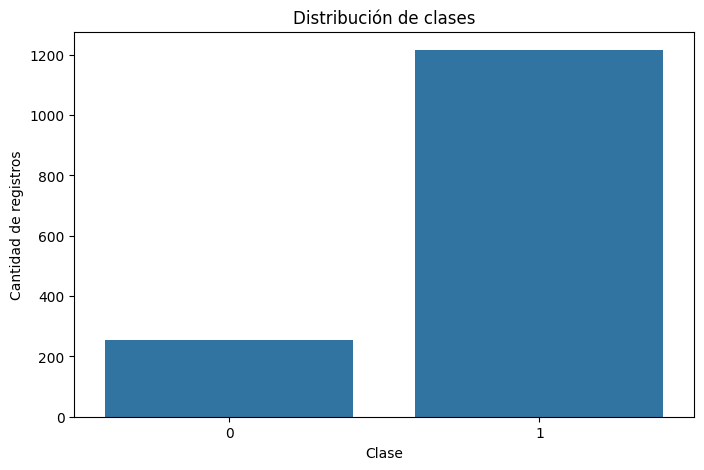

etiqueta
1    1216
0     256
Name: count, dtype: int64
etiqueta
1    82.608696
0    17.391304
Name: proportion, dtype: float64


In [8]:
# ============================================================
# 7. ANÁLISIS EXPLORATORIO DE DATOS - EDA
# ============================================================

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="etiqueta")
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad de registros")
plt.show()

print(df["etiqueta"].value_counts())
print(df["etiqueta"].value_counts(normalize=True) * 100)

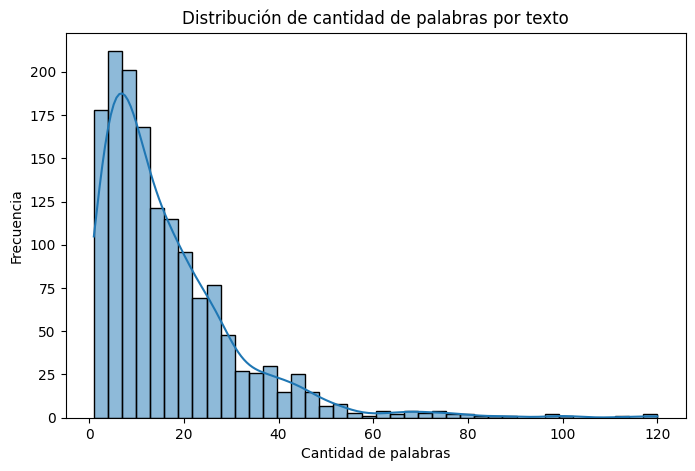

,longitud_caracteres,cantidad_palabras
count,1472.000000,1472.000000
mean,85.488451,16.404212
std,76.982300,14.915591
min,5.000000,1.000000
25%,33.000000,6.000000
50%,63.000000,12.000000
75%,115.000000,22.000000
max,636.000000,120.000000


In [9]:
# ============================================================
# 8. ANÁLISIS DE LONGITUD DE LOS TEXTOS
# ============================================================

df["longitud_caracteres"] = df["texto"].astype(str).apply(len)
df["cantidad_palabras"] = df["texto"].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(df["cantidad_palabras"], bins=40, kde=True)
plt.title("Distribución de cantidad de palabras por texto")
plt.xlabel("Cantidad de palabras")
plt.ylabel("Frecuencia")
plt.show()

df[["longitud_caracteres", "cantidad_palabras"]].describe()

In [10]:
# ============================================================
# 9. LIMPIEZA CON REGEX
# ============================================================

def limpiar_texto_regex(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+|www\S+|https\S+", " ", texto)
    texto = re.sub(r"@\w+", " ", texto)
    texto = re.sub(r"#", " ", texto)
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

df["texto_limpio"] = df["texto"].apply(limpiar_texto_regex)

df[["texto", "texto_limpio"]].head()

,texto,texto_limpio
0,"Está situado en el centro de la ciudad , con t...",está situado en el centro de la ciudad con tod...
1,"un lugar hermosisimo , inolvidable. hermosa at...",un lugar hermosisimo inolvidable hermosa atenc...
2,Todo absolutamente recomendable .,todo absolutamente recomendable
3,El metro está a 50 metros bajando tan solo una...,el metro está a metros bajando tan solo una calle
4,Y de Toscana ... mejor que lo veais ... y adem...,y de toscana mejor que lo veais y además delo ...


In [11]:
# ============================================================
# 10. PALABRAS MÁS FRECUENTES
# ============================================================

stopwords_es = set(stopwords.words("spanish"))

todas_las_palabras = []

for texto in df["texto_limpio"]:
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stopwords_es and len(p) > 2]
    todas_las_palabras.extend(palabras)

frecuencias = Counter(todas_las_palabras)
palabras_frecuentes = frecuencias.most_common(20)

df_frecuencias = pd.DataFrame(palabras_frecuentes, columns=["palabra", "frecuencia"])
df_frecuencias

,palabra,frecuencia
0,hotel,451
1,bien,156
2,personal,108
3,habitaciones,95
4,buena,88
5,habitación,84
6,buen,80
7,madrid,73
8,excelente,73
9,servicio,72


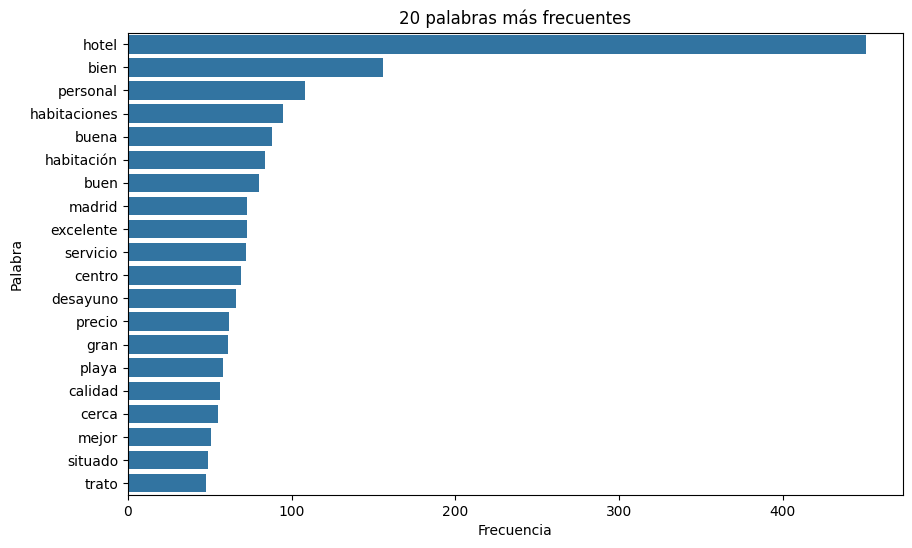

In [12]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_frecuencias, x="frecuencia", y="palabra")
plt.title("20 palabras más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.show()

In [15]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
# ============================================================
# 11. TOKENIZACIÓN Y NORMALIZACIÓN CON NLTK
# ============================================================

stemmer = SnowballStemmer("spanish")

def procesar_con_nltk(texto):
    tokens = word_tokenize(texto, language="spanish")
    tokens = [
        token for token in tokens
        if token not in stopwords_es and len(token) > 2
    ]

    # NLTK no posee un lematizador robusto integrado para español.
    # Por eso se usa SnowballStemmer como aproximación de normalización léxica.
    tokens_normalizados = [stemmer.stem(token) for token in tokens]

    return " ".join(tokens_normalizados)

df["texto_nltk"] = df["texto_limpio"].apply(procesar_con_nltk)

df[["texto_limpio", "texto_nltk"]].head()

,texto_limpio,texto_nltk
0,está situado en el centro de la ciudad con tod...,situ centr ciud turist alrededor pil ejempl si...
1,un lugar hermosisimo inolvidable hermosa atenc...,lug hermosisim inolvid hermos atencion rescat ...
2,todo absolutamente recomendable,absolut recomend
3,el metro está a metros bajando tan solo una calle,metr metr baj tan sol call
4,y de toscana mejor que lo veais y además delo ...,toscan mejor veais ademas del bonit florenci s...


In [17]:
# ============================================================
# 12. TOKENIZACIÓN Y LEMATIZACIÓN CON SPACY
# ============================================================

nlp = spacy.load("es_core_news_sm")

def procesar_con_spacy(texto):
    doc = nlp(texto)
    lemas = [
        token.lemma_ for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and len(token.lemma_) > 2
    ]
    return " ".join(lemas)

df["texto_spacy"] = df["texto_limpio"].apply(procesar_con_spacy)

df[["texto_limpio", "texto_nltk", "texto_spacy"]].head()

,texto_limpio,texto_nltk,texto_spacy
0,está situado en el centro de la ciudad con tod...,situ centr ciud turist alrededor pil ejempl si...,situado centro ciudad turístico pilar ejemplo ...
1,un lugar hermosisimo inolvidable hermosa atenc...,lug hermosisim inolvid hermos atencion rescat ...,lugar hermosisimo inolvidable hermoso atención...
2,todo absolutamente recomendable,absolut recomend,absolutamente recomendable
3,el metro está a metros bajando tan solo una calle,metr metr baj tan sol call,metro metro bajar calle
4,y de toscana mejor que lo veais y además delo ...,toscan mejor veais ademas del bonit florenci s...,toscana veais delo bonito florencia sienar per...


In [18]:
# ============================================================
# 13. COMPARACIÓN ENTRE NLTK Y SPACY
# ============================================================

muestra_comparacion = df[["texto_limpio", "texto_nltk", "texto_spacy"]].sample(10, random_state=SEED)
muestra_comparacion

,texto_limpio,texto_nltk,texto_spacy
852,fuí con el conocimiento de que es un hotel de ...,fui conoc hotel estrell ello sabi seri buen ho...,fuí conocimiento hotel estrella sabio seriar h...
184,wifi gratis en la habitacion,wifi gratis habit,wifi gratis habitacion
1261,además tiene una buena vista del vaticano,ademas buen vist vatican,vista vaticano
67,lo mismo con las sombrillas en la playa,mism sombrill play,sombrilla playa
220,nos robaron a campistas,rob campist,robar campista
494,la distancia del hotel a la playa permite que ...,distanci hotel play permit vay camin sin cuent...,distancia hotel playa permitir caminar contar ...
430,sin lugar a dudas es algo para repetir,lug dud repet,lugar duda repetir
240,atención excelente,atencion excelent,atención excelente
218,la categoria del camping se ha de reflejar en ...,categori camping reflej cas franc defraud,categoria camping reflejar caso francamente de...
49,estaba animado con ambientillo esquiador pero ...,anim ambientill esquiador agobi,animado ambientillo esquiador agobio


In [19]:
# ============================================================
# 14. SELECCIÓN DEL TEXTO PROCESADO PARA MODELADO
# ============================================================

# Para el modelo final usamos spaCy porque realiza lematización real en español.
df_modelo = df[["texto_spacy", "etiqueta"]].copy()
df_modelo.columns = ["texto", "etiqueta"]

df_modelo.head()

,texto,etiqueta
0,situado centro ciudad turístico pilar ejemplo ...,1
1,lugar hermosisimo inolvidable hermoso atención...,1
2,absolutamente recomendable,1
3,metro metro bajar calle,1
4,toscana veais delo bonito florencia sienar per...,1


In [20]:
# ============================================================
# 15. CODIFICACIÓN DE ETIQUETAS
# ============================================================

clases = sorted(df_modelo["etiqueta"].unique())
mapa_clases = {clase: i for i, clase in enumerate(clases)}
mapa_inverso = {i: clase for clase, i in mapa_clases.items()}

df_modelo["label"] = df_modelo["etiqueta"].map(mapa_clases)

print("Mapa de clases:")
print(mapa_clases)

df_modelo.head()

Mapa de clases:
{np.int64(0): 0, np.int64(1): 1}


,texto,etiqueta,label
0,situado centro ciudad turístico pilar ejemplo ...,1,1
1,lugar hermosisimo inolvidable hermoso atención...,1,1
2,absolutamente recomendable,1,1
3,metro metro bajar calle,1,1
4,toscana veais delo bonito florencia sienar per...,1,1


In [21]:
# ============================================================
# 16. DIVISIÓN EN TRAIN, VALIDACIÓN Y TEST
# ============================================================

X = df_modelo["texto"].values
y = df_modelo["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validación:", len(X_val))
print("Test:", len(X_test))

Train: 1030
Validación: 221
Test: 221


In [22]:
# ============================================================
# 17. REPRESENTACIÓN NUMÉRICA CON TF-IDF
# ============================================================

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.90
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("Dimensión TF-IDF train:", X_train_tfidf.shape)
print("Dimensión TF-IDF validación:", X_val_tfidf.shape)
print("Dimensión TF-IDF test:", X_test_tfidf.shape)

Dimensión TF-IDF train: (1030, 1100)
Dimensión TF-IDF validación: (221, 1100)
Dimensión TF-IDF test: (221, 1100)


In [23]:
# ============================================================
# 18. CONVERSIÓN A TENSORES PARA PYTORCH
# ============================================================

X_train_tensor = torch.tensor(X_train_tfidf.toarray(), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_tfidf.toarray(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_tfidf.toarray(), dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Datos preparados para PyTorch.")

Datos preparados para PyTorch.


In [24]:
# ============================================================
# 19. MODELO DE DEEP LEARNING EN PYTORCH
# ============================================================

class TextClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(TextClassifier, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.dropout1 = nn.Dropout(p=0.5)

        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.bn2 = nn.BatchNorm1d(hidden_dim // 2)
        self.dropout2 = nn.Dropout(p=0.5)

        self.fc3 = nn.Linear(hidden_dim // 2, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        return x

input_dim = X_train_tensor.shape[1]
hidden_dim = 256
output_dim = len(clases)

model = TextClassifier(input_dim, hidden_dim, output_dim).to(device)

print(model)

TextClassifier(
  (fc1): Linear(in_features=1100, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
  (relu): ReLU()
)


In [26]:
# ============================================================
# 20. CONFIGURACIÓN DEL ENTRENAMIENTO
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
patience = 5

best_val_loss = np.inf
epochs_without_improvement = 0

historial_train_loss = []
historial_val_loss = []
historial_val_acc = []

In [27]:
# ============================================================
# 21. FUNCIONES DE ENTRENAMIENTO Y VALIDACIÓN
# ============================================================

def entrenar_una_epoca(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluar(model, loader, criterion):
    model.eval()
    total_loss = 0
    predicciones = []
    reales = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            predicciones.extend(preds.cpu().numpy())
            reales.extend(y_batch.cpu().numpy())

    accuracy = accuracy_score(reales, predicciones)

    return total_loss / len(loader), accuracy, reales, predicciones

In [28]:
# ============================================================
# 22. ENTRENAMIENTO CON EARLY STOPPING
# ============================================================

for epoch in range(epochs):
    train_loss = entrenar_una_epoca(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _ = evaluar(model, val_loader, criterion)

    historial_train_loss.append(train_loss)
    historial_val_loss.append(val_loss)
    historial_val_acc.append(val_acc)

    print(f"Época {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "mejor_modelo.pt")
        print("Mejor modelo guardado.")
    else:
        epochs_without_improvement += 1
        print(f"Sin mejora: {epochs_without_improvement}/{patience}")

    if epochs_without_improvement >= patience:
        print("Early Stopping activado.")
        break

    print("-" * 60)

Época 1/50
Train Loss: 0.5554 | Val Loss: 0.5756 | Val Accuracy: 0.8281
Mejor modelo guardado.
------------------------------------------------------------
Época 2/50
Train Loss: 0.3610 | Val Loss: 0.5327 | Val Accuracy: 0.8281
Mejor modelo guardado.
------------------------------------------------------------
Época 3/50
Train Loss: 0.2535 | Val Loss: 0.5117 | Val Accuracy: 0.8326
Mejor modelo guardado.
------------------------------------------------------------
Época 4/50
Train Loss: 0.1933 | Val Loss: 0.4000 | Val Accuracy: 0.8462
Mejor modelo guardado.
------------------------------------------------------------
Época 5/50
Train Loss: 0.1580 | Val Loss: 0.3180 | Val Accuracy: 0.8371
Mejor modelo guardado.
------------------------------------------------------------
Época 6/50
Train Loss: 0.1124 | Val Loss: 0.3193 | Val Accuracy: 0.8507
Sin mejora: 1/5
------------------------------------------------------------
Época 7/50
Train Loss: 0.0951 | Val Loss: 0.3523 | Val Accuracy: 0.8371

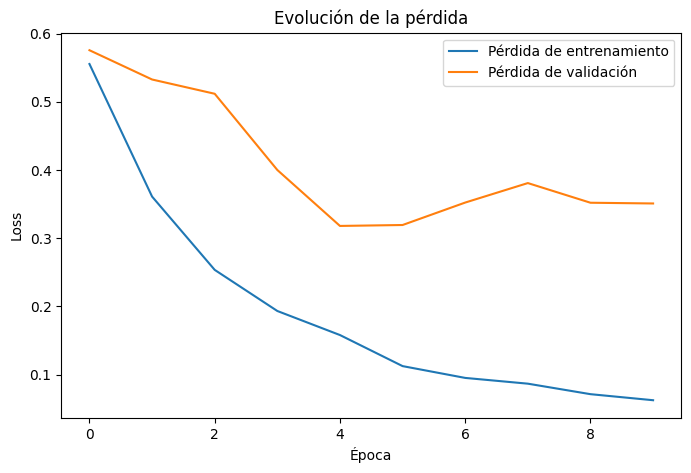

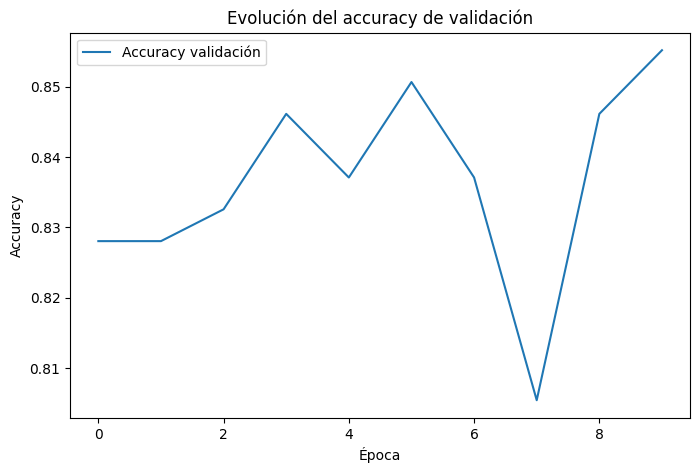

In [29]:
# ============================================================
# 23. VISUALIZACIÓN DEL ENTRENAMIENTO
# ============================================================

plt.figure(figsize=(8,5))
plt.plot(historial_train_loss, label="Pérdida de entrenamiento")
plt.plot(historial_val_loss, label="Pérdida de validación")
plt.title("Evolución de la pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(historial_val_acc, label="Accuracy validación")
plt.title("Evolución del accuracy de validación")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [30]:
# ============================================================
# 24. EVALUACIÓN FINAL EN TEST
# ============================================================

model.load_state_dict(torch.load("mejor_modelo.pt"))

test_loss, test_acc, y_reales, y_predichos = evaluar(model, test_loader, criterion)

print("Resultados finales en test")
print("Loss:", test_loss)
print("Accuracy:", test_acc)

Resultados finales en test
Loss: 0.3751443773508072
Accuracy: 0.8144796380090498


In [31]:
# ============================================================
# 25. REPORTE DE CLASIFICACIÓN
# ============================================================

nombres_clases = [str(mapa_inverso[i]) for i in range(len(mapa_inverso))]

print(classification_report(
    y_reales,
    y_predichos,
    target_names=nombres_clases
))

              precision    recall  f1-score   support

           0       0.48      0.51      0.49        39
           1       0.89      0.88      0.89       182

    accuracy                           0.81       221
   macro avg       0.69      0.70      0.69       221
weighted avg       0.82      0.81      0.82       221



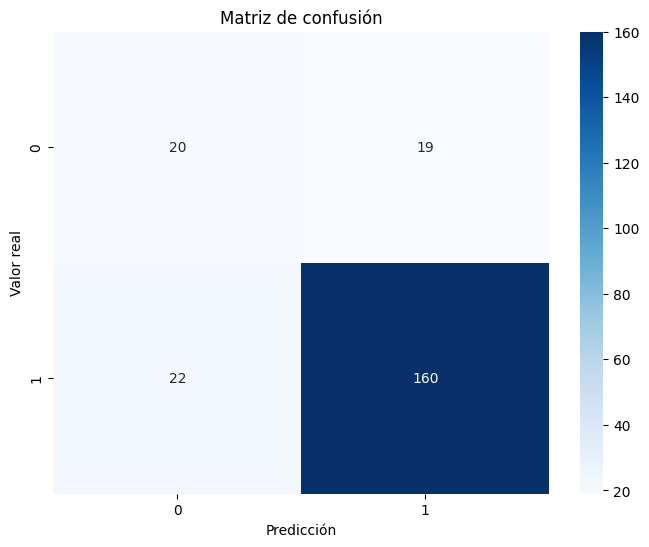

In [32]:
# ============================================================
# 26. MATRIZ DE CONFUSIÓN
# ============================================================

matriz = confusion_matrix(y_reales, y_predichos)

plt.figure(figsize=(8,6))
sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=nombres_clases,
    yticklabels=nombres_clases
)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [33]:
# ============================================================
# 27. PRUEBA CON TEXTOS NUEVOS
# ============================================================

def predecir_texto(texto):
    texto_limpio = limpiar_texto_regex(texto)
    texto_procesado = procesar_con_spacy(texto_limpio)
    texto_vectorizado = vectorizer.transform([texto_procesado])
    texto_tensor = torch.tensor(texto_vectorizado.toarray(), dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        output = model(texto_tensor)
        pred = torch.argmax(output, dim=1).item()

    return mapa_inverso[pred]

ejemplos = [
    "Me encantó el producto, funciona excelente y lo recomiendo mucho.",
    "Fue una experiencia horrible, no volvería a comprar.",
    "El servicio fue normal, nada especial."
]

for ejemplo in ejemplos:
    print("Texto:", ejemplo)
    print("Predicción:", predecir_texto(ejemplo))
    print("-" * 50)

Texto: Me encantó el producto, funciona excelente y lo recomiendo mucho.
Predicción: 1
--------------------------------------------------
Texto: Fue una experiencia horrible, no volvería a comprar.
Predicción: 1
--------------------------------------------------
Texto: El servicio fue normal, nada especial.
Predicción: 1
--------------------------------------------------
